In [1]:
%pip install -q pandas pyarrow datasets natasha tqdm matplotlib "setuptools<81"

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import itertools
from collections import Counter
from typing import List, Tuple, Set

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset

from natasha import (
    Segmenter, NewsEmbedding, NewsNERTagger, Doc, PER,
    MorphVocab, NamesExtractor
)

# Импорт из вашего пакета eval_core (абстракции)
from eval_core import (
    PIIModel, TextDocument, TextLine, Role, ParticipantKind,
    AnnotationSet, AnnotationLine, Span, EvaluationCase,
    Metric, Evaluator
)

TARGET_LABEL = "PER"   # только имена людей
SAMPLE_SIZE = 2000
RANDOM_SEED = 42

/home/ainmax/spring-school/natasha_eval/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Загрузка датасета...")
ds = load_dataset("wolframko/russian-pii-66k", split="train")

print("Фильтрация по русскому языку...")
ds = ds.filter(lambda x: x.get('language') == 'ru')

# Опциональная выборка, если не хотите обрабатывать все 66k примеров
SAMPLE_SIZE = 2000
RANDOM_SEED = 42
ds = ds.shuffle(seed=RANDOM_SEED).select(range(min(SAMPLE_SIZE, len(ds))))
print(f"Загружено {len(ds)} примеров")

Загрузка датасета...


Фильтрация по русскому языку...


Filter: 100%|██████████| 65652/65652 [00:00<00:00, 86557.64 examples/s]

Загружено 2000 примеров


In [26]:
def build_cases(dataset):
    cases = []
    role = Role(name="text", kind=ParticipantKind.UNKNOWN)
    for idx, record in enumerate(tqdm(dataset, desc="Построение EvaluationCase")):
        text = record.get("source_text") or ""
        if not text.strip():
            continue
        annotations = record.get("privacy_mask") or []
        
        # Собираем все спаны с метками GIVENNAME и SURNAME
        name_spans = []
        for ann in annotations:
            label = ann.get("label")
            if label not in ('GIVENNAME', 'SURNAME'):
                continue
            start = ann.get("start")
            end = ann.get("end")
            if start is None or end is None:
                continue
            name_spans.append((int(start), int(end)))
        
        # Сортируем по начальной позиции
        name_spans.sort(key=lambda x: x[0])
        
        # Объединяем соседние спаны (если расстояние <= 2 символа)
        merged_spans = []
        i = 0
        while i < len(name_spans):
            start, end = name_spans[i]
            j = i + 1
            while j < len(name_spans) and name_spans[j][0] <= end + 2:
                end = max(end, name_spans[j][1])
                j += 1
            merged_spans.append(Span(
                line_idx=0,
                begin=start,
                end=end,
                label="PER",
                data=text[start:end]
            ))
            i = j
        
        text_line = TextLine(idx=0, role=role, text=text)
        document = TextDocument(lines=(text_line,), sample_id=str(idx))
        target = AnnotationSet(lines=(AnnotationLine(idx=0, role=role, spans=merged_spans),))
        cases.append(EvaluationCase(document=document, target=target))
    return cases

cases = build_cases(ds)

Построение EvaluationCase: 100%|██████████| 2000/2000 [00:00<00:00, 24003.39it/s]


In [27]:
all_labels = set()
for record in ds:
    for ann in record.get("privacy_mask", []):
        all_labels.add(ann.get("label"))
print("Все уникальные метки в датасете:", all_labels)

Все уникальные метки в датасете: {'TAXNUM', 'SURNAME', 'DRIVERLICENSENUM', 'STREET', 'GIVENNAME', 'USERNAME', 'SOCIALNUM', 'ACCOUNTNUM', 'CREDITCARDNUMBER', 'TELEPHONENUM', 'EMAIL', 'BUILDINGNUM', 'IDCARDNUM', 'PASSWORD', 'ZIPCODE', 'CITY', 'DATEOFBIRTH'}


In [28]:
# Инициализация компонентов Natasha (один раз)
segmenter = Segmenter()
emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)
morph_vocab = MorphVocab()
names_extractor = NamesExtractor(morph_vocab)

def predict_natasha_per(text: str) -> List[Span]:
    """Возвращает список спанов PER, найденных Natasha."""
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)
    spans = []
    for span in doc.spans:
        if span.type != PER:
            continue
        spans.append(Span(
            line_idx=0,
            begin=span.start,
            end=span.stop,
            label="PER",
            data=span.text
        ))
    return spans

class NatashaPERModel(PIIModel):
    def process(self, document: TextDocument) -> AnnotationSet:
        if not document.lines:
            return AnnotationSet(lines=())
        text = document.lines[0].text
        pred_spans = predict_natasha_per(text)
        ann_line = AnnotationLine(idx=0, role=document.lines[0].role, spans=pred_spans)
        return AnnotationSet(lines=(ann_line,))

In [29]:
class CharacterBinaryPRF(Metric):
    def __init__(self, label: str = "PER"):
        self.label = label
        self.reset()

    @property
    def name(self) -> str:
        return f"char_binary_{self.label}"

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.tn = 0

    def update(self, case: EvaluationCase, model_prediction: AnnotationSet):
        # Получаем текст документа (одна строка)
        text = case.document.lines[0].text
        length = len(text)

        # Gold-маска: символ входит в PER-сущность?
        gold_mask = [False] * length
        for span in case.target.lines[0].spans:
            for pos in range(span.begin, span.end):
                gold_mask[pos] = True

        # Pred-маска
        pred_mask = [False] * length
        for span in model_prediction.lines[0].spans:
            for pos in range(span.begin, span.end):
                pred_mask[pos] = True

        # Подсчёт TP, FP, FN, TN
        for g, p in zip(gold_mask, pred_mask):
            if g and p:
                self.tp += 1
            elif not g and p:
                self.fp += 1
            elif g and not p:
                self.fn += 1
            else:
                self.tn += 1

    def compute(self):
        precision = self.tp / (self.tp + self.fp) if self.tp + self.fp else 0.0
        recall = self.tp / (self.tp + self.fn) if self.tp + self.fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        return {"precision": precision, "recall": recall, "f1": f1}

In [30]:
class SpanExactMatchPRF(Metric):
    def __init__(self, label: str = "PER"):
        self.label = label
        self.reset()

    @property
    def name(self) -> str:
        return f"span_exact_{self.label}"

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0

    def update(self, case: EvaluationCase, model_prediction: AnnotationSet):
        gold_spans = set()
        for span in case.target.lines[0].spans:
            if span.label == self.label:
                gold_spans.add((span.begin, span.end, span.label))

        pred_spans = set()
        for span in model_prediction.lines[0].spans:
            if span.label == self.label:
                pred_spans.add((span.begin, span.end, span.label))

        self.tp += len(gold_spans & pred_spans)
        self.fp += len(pred_spans - gold_spans)
        self.fn += len(gold_spans - pred_spans)

    def compute(self):
        precision = self.tp / (self.tp + self.fp) if self.tp + self.fp else 0.0
        recall = self.tp / (self.tp + self.fn) if self.tp + self.fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        return {"precision": precision, "recall": recall, "f1": f1}

In [32]:
print("Всего сэмплов в cases:", len(cases))

if len(cases) > 0:
    first = cases[2]
    print("\nПервый документ (первые 200 символов):")
    print(first.document.lines[0].text[:200])
    print("\nЗолотые спаны (PER):")
    print(first.target.lines[0].spans)
else:
    print("Нет ни одного сэмпла!")

Всего сэмплов в cases: 2000

Первый документ (первые 200 символов):
Добрый день, Мария Денисова! Подтверждаем ваш рейс из г. Слюдянка; билеты отправлены на luchezar01@example.com.

Золотые спаны (PER):
[Span(line_idx=0, begin=13, end=27, label='PER', data='Мария Денисова')]


In [33]:
sample_text = cases[1].document.lines[0].text
pred_spans = predict_natasha_per(sample_text)
print("Natasha предсказала:")
for s in pred_spans:
    print(f"  {s.data} [{s.begin}:{s.end}]")

Natasha предсказала:


Number of cases: 2000
Gold spans in first case: []
Predicted spans in first case: []

Six metrics:
char_binary_PER_precision 0.892292
char_binary_PER_recall    0.972527
char_binary_PER_f1        0.930683
span_exact_PER_precision  0.838298
span_exact_PER_recall     0.915215
span_exact_PER_f1         0.875069

DataFrame:
                              value
char_binary_PER_precision  0.892292
char_binary_PER_recall     0.972527
char_binary_PER_f1         0.930683
span_exact_PER_precision   0.838298
span_exact_PER_recall      0.915215
span_exact_PER_f1          0.875069


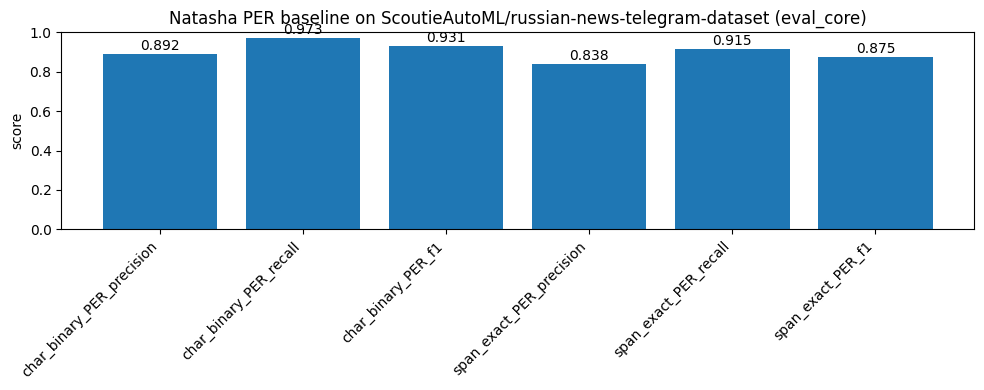

In [34]:
# Создаём модель и метрики
model = NatashaPERModel()
metrics = [
    CharacterBinaryPRF(label="PER"),
    SpanExactMatchPRF(label="PER")
]

# Диагностика: проверим, что cases не пуст и первые спаны непустые
print("Number of cases:", len(cases))
if len(cases) > 0:
    print("Gold spans in first case:", cases[0].target.lines[0].spans)
    pred_first = model.process(cases[0].document)
    print("Predicted spans in first case:", pred_first.lines[0].spans)

# Запускаем оценку
evaluator = Evaluator(cases)   # <--- исправлено: dataset -> cases
report = evaluator.eval_model(model, metrics)

# Извлекаем шесть значений
results = {}
for metric_name, metric_results in report.metrics.items():
    for m in ["precision", "recall", "f1"]:
        key = f"{metric_name}_{m}"
        results[key] = metric_results[m]

# Выводим в виде таблицы
print("\nSix metrics:")
for k, v in results.items():
    print(f"{k:25} {v:.6f}")

# Для наглядности – DataFrame
df_results = pd.DataFrame([results]).T
df_results.columns = ["value"]
print("\nDataFrame:")
print(df_results)

# График (опционально)
plot_df = pd.DataFrame({
    "metric": list(results.keys()),
    "value": list(results.values())
})
plt.figure(figsize=(10, 4))
plt.bar(plot_df["metric"], plot_df["value"])
plt.ylim(0, 1)
plt.ylabel("score")
plt.title("Natasha PER baseline on ScoutieAutoML/russian-news-telegram-dataset (eval_core)")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(plot_df["value"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()